# Velocity Scale Ablation Study

This notebook compares the velocity-scale ablation runs from Weights & Biases.

Each plot shows one metric against **epoch** up to epoch **1100**. The compared runs are:

- No scaling
- 1/(4π)
- 1/(2π)
- 1/π
- 2/π

The plots use high-contrast colors and different line styles for easier comparison.

In [1]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import wandb

MAX_EPOCH = 1100
ENTITY = "xanderbaatz-danmarks-tekniske-universitet-dtu"

ROOT = Path.cwd().resolve()
if not (ROOT / 'reports').exists() and (ROOT.parent / 'reports').exists():
    ROOT = ROOT.parent
FIGURE_DIR = ROOT / 'reports' / 'figures' / 'velocity_scale_ablation'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_SIZE = (7.0, 4.5)
FIGURE_DPI = 300
LINE_WIDTH = 2.0
TITLE_SIZE = 10
LABEL_SIZE = 9
TICK_SIZE = 8
LEGEND_SIZE = 6.0
ANNOTATION_SIZE = 7.0

RUNS = [
    {
        "label": "1/(2π)",
        "project": "mp20_lattice_eps_em",
        "run_id": "w41cll5b",
        "color": "#000000",
        "linestyle": "-",
    },
    {
        "label": "2/π",
        "project": "AblationStudyVelScale_2OverPi",
        "run_id": "pmd5hauj",
        "color": "#0072B2",
        "linestyle": "--",
    },
    {
        "label": "1/π",
        "project": "AblationStudyVelScale_1Pi",
        "run_id": "k57g5zrv",
        "color": "#D55E00",
        "linestyle": "-.",
    },
    {
        "label": "1/(4π)",
        "project": "AblationStudyVelScale_4Pi",
        "run_id": "3usx62u3",
        "color": "#009E73",
        "linestyle": ":",
    },
    {
        "label": "No scaling",
        "project": "AblationStudyVelScale_NoScale",
        "run_id": "dgbi4imd",
        "color": "#CC79A7",
        "linestyle": (0, (5, 2, 1, 2)),
    },
]

METRICS = [
    "train/loss_v",
    "train/loss_l",
    "train/loss_weighted",
    "val/rmse",
    "val/valid",
    "val/match_rate",
]

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/vscode/.netrc.


In [ ]:
def fetch_run_data(project: str, run_id: str) -> pd.DataFrame:
    run = api.run(f"{ENTITY}/{project}/{run_id}")
    history = run.history(keys=["epoch", *METRICS], pandas=True)
    history = history.dropna(subset=["epoch"]).copy()
    history = history[history["epoch"] <= MAX_EPOCH]
    history["epoch"] = history["epoch"].astype(float)
    return history


all_histories = {
    f"{run['project']}/{run['run_id']}": fetch_run_data(run["project"], run["run_id"])
    for run in RUNS
}


def _metric_svg_path(metric: str) -> Path:
    return FIGURE_DIR / f"{metric.replace('/', '_')}.svg"


def plot_metric(metric: str, title: str, annotate_last: bool = False) -> None:
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    endpoints: list[tuple[float, float, str, dict[str, object]]] = []

    for run in RUNS:
        run_key = f"{run['project']}/{run['run_id']}"
        history = all_histories.get(run_key)
        if history is None or history.empty or metric not in history.columns:
            continue

        subset = history[["epoch", metric]].dropna().sort_values("epoch")
        if subset.empty:
            continue

        style = {
            "color": run["color"],
            "linestyle": run["linestyle"],
        }
        ax.plot(
            subset["epoch"],
            subset[metric],
            label=run["label"],
            linewidth=LINE_WIDTH,
            **style,
        )

        if annotate_last:
            last = subset.iloc[-1]
            endpoints.append((
                float(last["epoch"]),
                float(last[metric]),
                run["label"],
                style,
            ))

    if annotate_last and endpoints:
        endpoints.sort(key=lambda item: item[1])
        y_positions = [item[1] for item in endpoints]
        y_min = min(y_positions)
        y_max = max(y_positions)
        span = max(y_max - y_min, 1e-6)
        min_gap = max(span * 0.06, 0.01)

        adjusted = []
        for value in y_positions:
            if not adjusted:
                adjusted.append(value)
            else:
                adjusted.append(max(value, adjusted[-1] + min_gap))

        if adjusted:
            upper = y_max + min_gap
            overflow = adjusted[-1] - upper
            if overflow > 0:
                adjusted = [value - overflow for value in adjusted]
                lower = y_min - min_gap
                underflow = lower - adjusted[0]
                if underflow > 0:
                    adjusted = [value + underflow for value in adjusted]

        x_max = max(item[0] for item in endpoints)
        x_text = x_max + max(4.0, x_max * 0.015)

        for (x, original_y, label, style), y_text in zip(endpoints, adjusted):
            color = style.get("color", "black")
            ax.annotate(
                f"{label}: {original_y:.4f}",
                xy=(x, original_y),
                xytext=(x_text, y_text),
                textcoords="data",
                color=color,
                fontsize=ANNOTATION_SIZE,
                va="center",
                arrowprops={"arrowstyle": "-", "color": color, "lw": 0.9},
                bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": color, "alpha": 0.9},
                clip_on=False,
            )

        ax.set_xlim(right=x_text + max(5.0, x_max * 0.03))

    ax.set_title(title, fontsize=TITLE_SIZE)
    ax.set_xlabel("Epoch", fontsize=LABEL_SIZE)
    ax.set_ylabel(metric, fontsize=LABEL_SIZE)
    ax.tick_params(axis='both', labelsize=TICK_SIZE)
    ax.grid(True, alpha=0.3, linewidth=0.6)
    ax.legend(frameon=True, fontsize=LEGEND_SIZE, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
    fig.tight_layout(rect=(0, 0, 0.80, 1))
    svg_path = _metric_svg_path(metric)
    fig.savefig(svg_path, format='svg', dpi=FIGURE_DPI, bbox_inches='tight', transparent=True)
    print(f'saved {svg_path}')
    plt.show()
    plt.close(fig)


In [3]:
summary_rows = []
for run in RUNS:
    label = run["label"]
    run_key = f"{run['project']}/{run['run_id']}"
    history = all_histories.get(run_key)
    row = {"run": label}

    for metric in METRICS:
        if history is None or history.empty or metric not in history.columns:
            row[metric] = None
            continue

        series = history[[metric]].dropna()
        row[metric] = None if series.empty else float(series.iloc[-1][metric])

    summary_rows.append(row)

pd.DataFrame(summary_rows)


,run,train/loss_v,train/loss_l,train/loss_weighted,val/rmse,val/valid,val/match_rate
0,1/(2π),0.205678,0.009188,0.214866,0.099002,0.995117,0.593750
1,2/π,0.664680,0.010614,0.675294,0.144665,0.994141,0.512695
2,1/π,0.484213,0.010578,0.494791,0.120060,0.995117,0.597656
3,1/(4π),0.087500,0.009018,0.096518,0.256303,0.995117,0.214844
4,No scaling,0.682747,0.012400,0.695146,0.149420,0.990234,0.535156


saved /workspace/reports/figures/velocity_scale_ablation/train_loss_v.svg


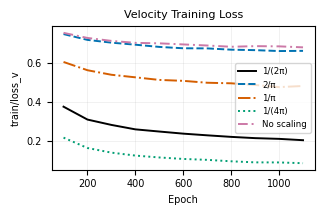

In [4]:
plot_metric('train/loss_v', 'Velocity Training Loss')

saved /workspace/reports/figures/velocity_scale_ablation/train_loss_l.svg


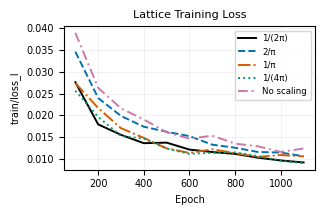

In [5]:
plot_metric('train/loss_l', 'Lattice Training Loss')

saved /workspace/reports/figures/velocity_scale_ablation/train_loss_weighted.svg


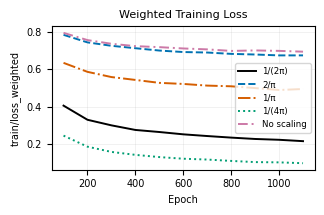

In [6]:
plot_metric('train/loss_weighted', 'Weighted Training Loss')

saved /workspace/reports/figures/velocity_scale_ablation/val_rmse.svg


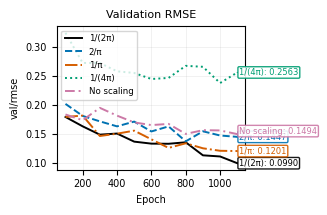

In [7]:
plot_metric('val/rmse', 'Validation RMSE', annotate_last=True)

/tmp/ipykernel_16652/3947963938.py:107: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


saved /workspace/reports/figures/velocity_scale_ablation/val_valid.svg


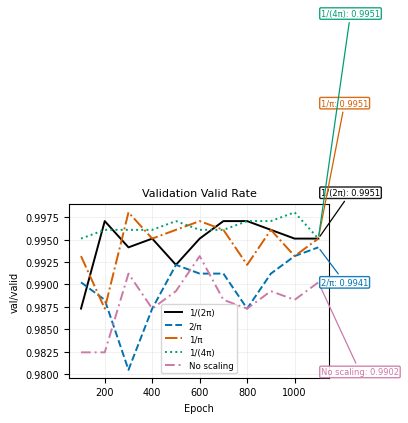

In [8]:
plot_metric('val/valid', 'Validation Valid Rate', annotate_last=True)

saved /workspace/reports/figures/velocity_scale_ablation/val_match_rate.svg


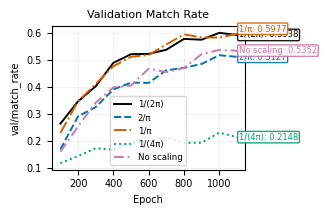

In [9]:
plot_metric('val/match_rate', 'Validation Match Rate', annotate_last=True)

In [10]:
summary_df = pd.DataFrame(summary_rows).rename(columns={
    'run': 'model',
    'val/rmse': 'rmse',
    'val/valid': 'valid',
    'val/match_rate': 'match_rate',
})

final_table = summary_df[['model', 'match_rate', 'rmse', 'valid']].copy()
display(final_table)


,model,match_rate,rmse,valid
0,1/(2π),0.593750,0.099002,0.995117
1,2/π,0.512695,0.144665,0.994141
2,1/π,0.597656,0.120060,0.995117
3,1/(4π),0.214844,0.256303,0.995117
4,No scaling,0.535156,0.149420,0.990234
